**Project Title: Based Image Processing Pipeline for Big Data Analytics**

**Project Objectives:**

1. Build an OpenCV-based image processing pipeline for core computer vision operations — reading, writing, and transforming images.

2. Implement geometric transformations — rotation, mirroring, and directional cropping — for spatial image manipulation.

3. Develop grid-based segmentation (4, 8, and 16-cell grids) to simulate partitioning visual data for distributed processing.

4. Apply compression and color-space conversion (grayscale/binary) to optimize storage and processing efficiency.

5. Package all operations as reusable functions in a modular Colab notebook, usable as a backend utility for big data analytics applications.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

os.makedirs("outputs", exist_ok=True)

def show(img, title="Image"):
    # OpenCV loads BGR, matplotlib expects RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if len(img.shape) == 3 else img
    plt.figure(figsize=(5,5))
    plt.imshow(img_rgb, cmap='gray' if len(img.shape)==2 else None)
    plt.title(title)
    plt.axis('off')
    plt.show()

Saving shutterstock_2499837849-1024x576.jpg to shutterstock_2499837849-1024x576.jpg
Image shape: (576, 1024, 3)


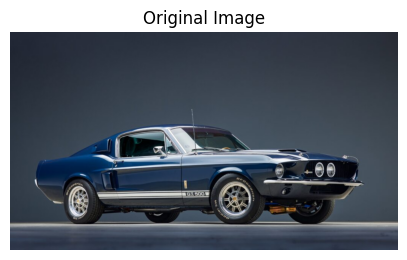

In [ ]:
uploaded = files.upload()  # pick your image when prompted
img_path = list(uploaded.keys())[0]

original = cv2.imread(img_path)
print("Image shape:", original.shape)
show(original, "Original Image")

Original: 61.8 KB  ->  Compressed: 30.1 KB


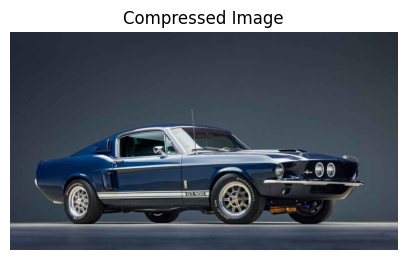

In [ ]:
compressed_path = "outputs/compressed.jpg"

# JPEG quality 0-100, lower = more compression
cv2.imwrite(compressed_path, original, [cv2.IMWRITE_JPEG_QUALITY, 40])

orig_size = os.path.getsize(img_path) / 1024
comp_size = os.path.getsize(compressed_path) / 1024
print(f"Original: {orig_size:.1f} KB  ->  Compressed: {comp_size:.1f} KB")

compressed = cv2.imread(compressed_path)
show(compressed, "Compressed Image")

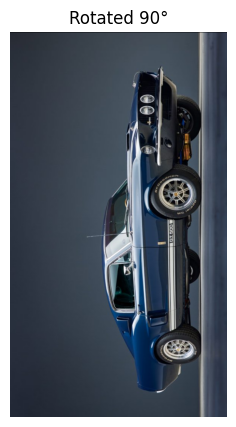

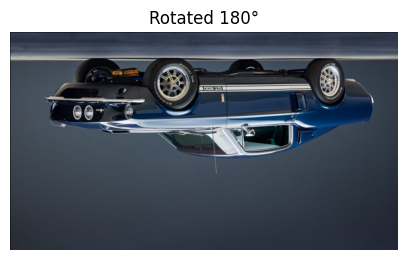

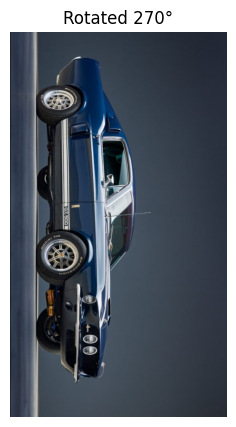

In [ ]:
def rotate_image(image, angle):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # for 90/270 degree turns, width and height swap
    if angle % 180 == 90 or angle % 180 == -90:
        new_w, new_h = h, w
    else:
        new_w, new_h = w, h

    M[0, 2] += (new_w / 2) - center[0]
    M[1, 2] += (new_h / 2) - center[1]
    return cv2.warpAffine(image, M, (new_w, new_h))

rot_90  = rotate_image(original, 90)
rot_180 = rotate_image(original, 180)
rot_270 = rotate_image(original, 270)

cv2.imwrite("outputs/rotate_90.jpg", rot_90)
cv2.imwrite("outputs/rotate_180.jpg", rot_180)
cv2.imwrite("outputs/rotate_270.jpg", rot_270)

show(rot_90, "Rotated 90°")
show(rot_180, "Rotated 180°")
show(rot_270, "Rotated 270°")

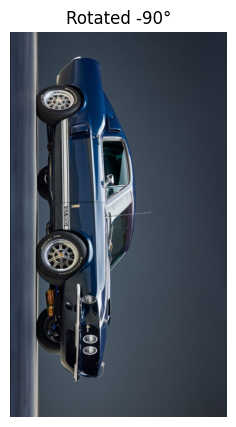

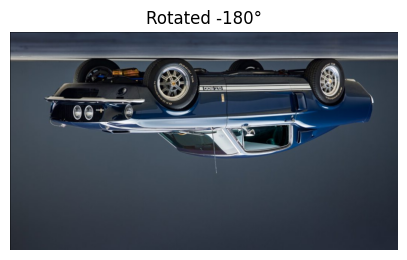

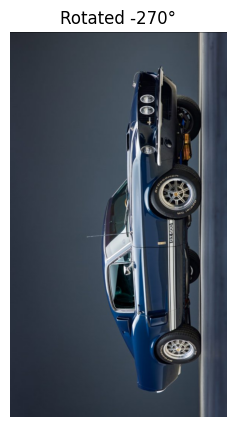

In [ ]:
rot_neg90  = rotate_image(original, -90)
rot_neg180 = rotate_image(original, -180)
rot_neg270 = rotate_image(original, -270)

cv2.imwrite("outputs/rotate_-90.jpg", rot_neg90)
cv2.imwrite("outputs/rotate_-180.jpg", rot_neg180)
cv2.imwrite("outputs/rotate_-270.jpg", rot_neg270)

show(rot_neg90, "Rotated -90°")
show(rot_neg180, "Rotated -180°")
show(rot_neg270, "Rotated -270°")

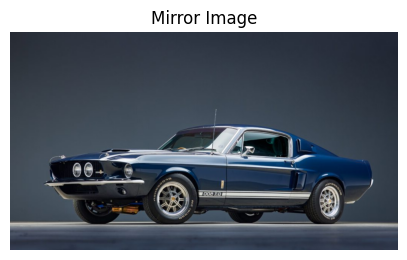

In [ ]:
mirror = cv2.flip(original, 1)  # 1 = horizontal flip (left-right mirror)
cv2.imwrite("outputs/mirror.jpg", mirror)
show(mirror, "Mirror Image")

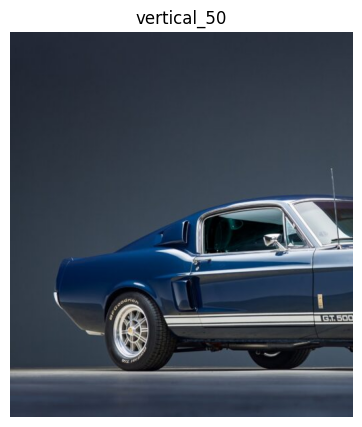

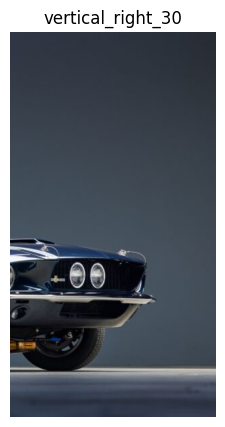

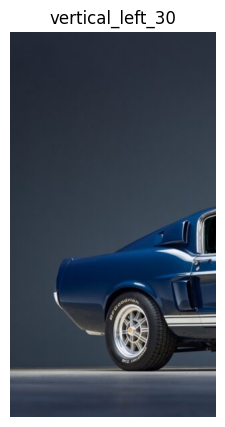

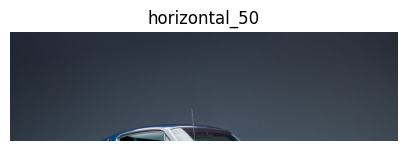

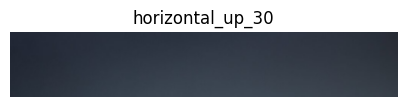

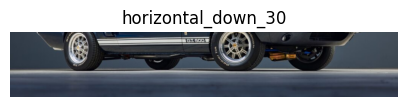

In [ ]:
h, w = original.shape[:2]

# Vertical cuts (cutting along width)
vertical_50      = original[:, :w//2]               # left half
vertical_right30 = original[:, int(w*0.7):]         # rightmost 30%
vertical_left30  = original[:, :int(w*0.3)]         # leftmost 30%

# Horizontal cuts (cutting along height)
horizontal_50    = original[:h//2, :]               # top half
horizontal_up30  = original[:int(h*0.3), :]         # top 30%
horizontal_down30= original[int(h*0.7):, :]         # bottom 30%

crops = {
    "vertical_50": vertical_50,
    "vertical_right_30": vertical_right30,
    "vertical_left_30": vertical_left30,
    "horizontal_50": horizontal_50,
    "horizontal_up_30": horizontal_up30,
    "horizontal_down_30": horizontal_down30
}

for name, crop in crops.items():
    cv2.imwrite(f"outputs/{name}.jpg", crop)
    show(crop, name)

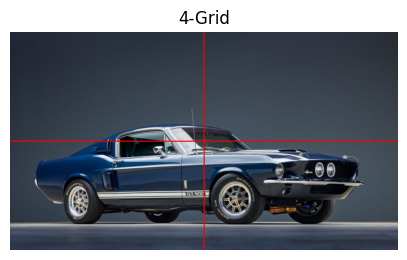

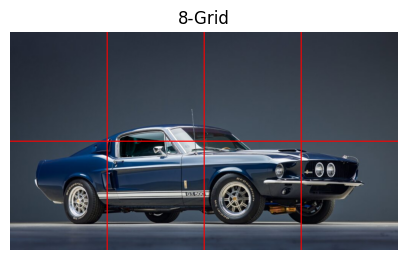

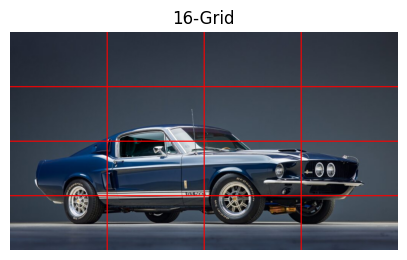

In [ ]:
def draw_grid(image, rows, cols, color=(0, 0, 255), thickness=2):
    out = image.copy()
    h, w = out.shape[:2]
    for i in range(1, cols):
        x = int(w * i / cols)
        cv2.line(out, (x, 0), (x, h), color, thickness)
    for i in range(1, rows):
        y = int(h * i / rows)
        cv2.line(out, (0, y), (w, y), color, thickness)
    return out

grid_4  = draw_grid(original, rows=2, cols=2)   # 2x2 = 4 cells
grid_8  = draw_grid(original, rows=2, cols=4)   # 2x4 = 8 cells
grid_16 = draw_grid(original, rows=4, cols=4)   # 4x4 = 16 cells

cv2.imwrite("outputs/grid_4.jpg", grid_4)
cv2.imwrite("outputs/grid_8.jpg", grid_8)
cv2.imwrite("outputs/grid_16.jpg", grid_16)

show(grid_4, "4-Grid")
show(grid_8, "8-Grid")
show(grid_16, "16-Grid")

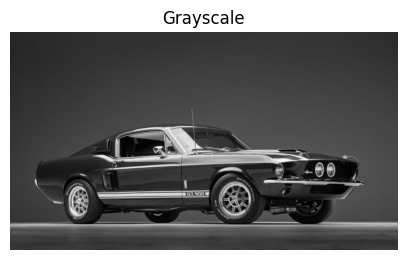

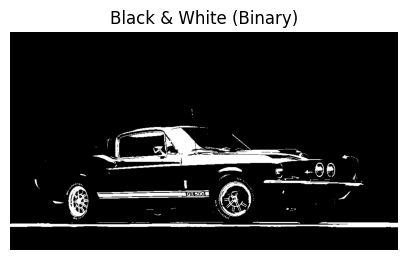

In [ ]:
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
# true binary black & white (pure 0/255)
_, bw = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

cv2.imwrite("outputs/grayscale.jpg", gray)
cv2.imwrite("outputs/black_white.jpg", bw)

show(gray, "Grayscale")
show(bw, "Black & White (Binary)")

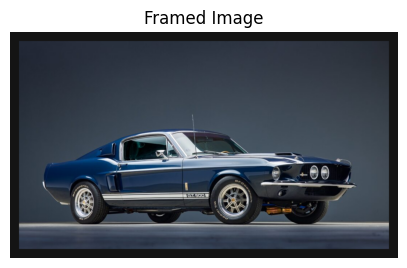

In [ ]:
framed = cv2.copyMakeBorder(
    original, top=25, bottom=25, left=25, right=25,
    borderType=cv2.BORDER_CONSTANT, value=(20, 20, 20)  # dark frame, change color as needed
)

cv2.imwrite("outputs/framed.jpg", framed)
show(framed, "Framed Image")

In [ ]:
import shutil
shutil.make_archive("cv_outputs", "zip", "outputs")
files.download("cv_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

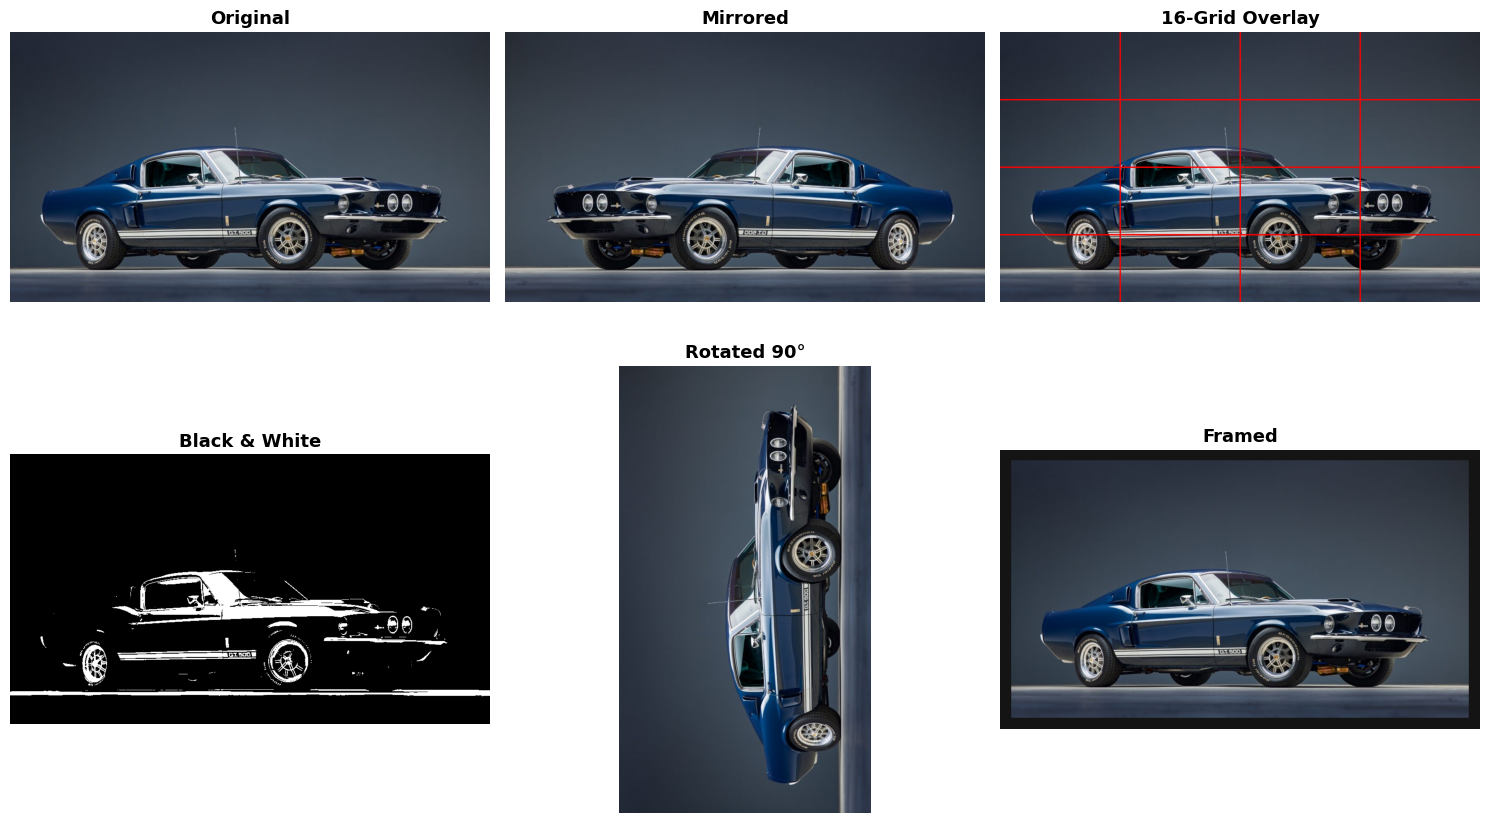

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import cv2

images_for_post = [
    (original, "Original"),
    (mirror, "Mirrored"),
    (grid_16, "16-Grid Overlay"),
    (bw, "Black & White"),
    (rot_90, "Rotated 90°"),
    (framed, "Framed")
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (img, title) in zip(axes.flat, images_for_post):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if len(img.shape) == 3 else img
    ax.imshow(img_rgb, cmap='gray' if len(img.shape) == 2 else None)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig("outputs/linkedin_collage.jpg", dpi=200, bbox_inches='tight')
plt.show()

files.download("outputs/linkedin_collage.jpg")

**Conclusion**

 This project implements a modular image processing pipeline using OpenCV, covering compression, geometric transformations, directional cropping, grid-based segmentation, color-space conversion, and framing. Built as reusable functions, the pipeline demonstrates practical computer vision fundamentals and lays the groundwork for scaling these techniques into larger big data analytics workflows that process visual data at volume.